# 04 - Generate a REBALANCED Synthetic Dataset

**The bug this notebook fixes.** Your v2 looped over every row in
`metadata.jsonl` and generated an image from *that row's own mask*. Every
synthetic image therefore had the same layout, the same objects, the same boxes
and — fatally — **the same class distribution as the real image it came from**.
That is 15 hours of GPU time to reproduce your existing imbalance exactly.

**What this version does instead.** It composes **new** masks first: a rare-class
region is lifted from a mask where it appears and placed into a *different*
mask, at a position and scale sampled from where that class really occurs. Then
ControlNet paints a fresh image from the modified layout.

Because the edit happens in **mask space**, there are no paste seams, no
blending artefacts and no illumination mismatch — the diffusion model repaints
the entire frame from the layout. And since you built the layout, the YOLO
labels come out exact and free.

Run order: quality gate (cell 4) -> build bank (5-6) -> compose (7) -> generate (8) -> labels (9).

**Restart the kernel before running this** if you just trained — the training
process may still be holding VRAM.

In [1]:
# 1. Install
!pip install diffusers accelerate transformers opencv-python --quiet

In [13]:
# 2. Config + load palette
import json, random, collections, math
from pathlib import Path

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

PROJECT_ROOT    = Path(r"D:\Study\CDC Project 1\Project")
CONTROLNET_ROOT = PROJECT_ROOT / "data" / "controlnet"
BASE_MODEL      = "stable-diffusion-v1-5/stable-diffusion-v1-5"

# Point at the FINAL output dir once training is done. A checkpoint subdir works
# too, but anything under ~4000 steps has not learned to follow the mask yet and
# will mislead you about whether this approach works.
# CONTROLNET_DIR = PROJECT_ROOT / "controlnet_output"
CONTROLNET_DIR = PROJECT_ROOT / "controlnet_output" / "checkpoint-24000" / "controlnet"

SYN_ROOT     = PROJECT_ROOT / "data" / "synthetic"
SYN_IMG_DIR  = SYN_ROOT / "images"
SYN_COND_DIR = SYN_ROOT / "conditioning_images"
SYN_DET_DIR  = SYN_ROOT / "labels"          # YOLO detection labels
SYN_SEG_DIR  = SYN_ROOT / "labels_seg"      # YOLO segmentation labels
for d in (SYN_IMG_DIR, SYN_COND_DIR, SYN_DET_DIR, SYN_SEG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- knobs ------------------------------------------------------------------
RARE_CLASSES     = []      # COCO category ids to boost. [] = auto-pick 3 rarest.
TARGET_PER_CLASS = 800     # desired synthetic instances per rare class
MAX_PASTES       = 2       # rare objects added per composed frame
INFER_STEPS      = 20      # UniPC is good at 20; 30 is ~50% slower for little gain
GUIDANCE         = 7.5
BATCH            = 2       # inference batch. Drop to 1 on OOM.
BANK_SAMPLE      = 1500    # frames sampled for placement statistics
SEED             = 1234
NEGATIVE_PROMPT  = "blurry, low quality, distorted anatomy, cartoon, unrealistic, text, watermark"
# -----------------------------------------------------------------------------

pal_raw = json.loads((CONTROLNET_ROOT / "palette.json").read_text())
SIZE        = pal_raw["size"]
palette     = {int(k): tuple(v) for k, v in pal_raw["palette"].items()}
names       = {int(k): v for k, v in pal_raw["names"].items()}
cid_to_yolo = {int(k): int(v) for k, v in pal_raw["cid_to_yolo"].items()}
yolo_names  = pal_raw["yolo_names"]

records = [json.loads(l) for l in open(CONTROLNET_ROOT / "metadata.jsonl", encoding="utf-8")]
train_records = [r for r in records if r.get("split", "train") == "train"]
assert train_records, "No train rows -- rerun notebook 02."

print(f"size={SIZE}  train rows={len(train_records)}  classes={len(names)}")
for cid, nm in names.items():
    print(f"  {cid:>2} {nm:<28} yolo_idx={cid_to_yolo[cid]}")

# Compose ONLY from train-split masks. Using val masks would leak held-out
# layouts into training data and quietly inflate every number you report.
rng = random.Random(SEED)

size=512  train rows=8200  classes=8
   1 external iliac artery        yolo_idx=0
   2 external iliac vein          yolo_idx=1
   3 obturator nerve              yolo_idx=2
   4 ovary                        yolo_idx=3
   5 ureter                       yolo_idx=4
   6 uterine artery               yolo_idx=5
   7 uterus                       yolo_idx=6
   8 instruments                  yolo_idx=7


In [14]:
# 3. Load the pipeline
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

assert CONTROLNET_DIR.exists(), f"Missing {CONTROLNET_DIR} -- train first (notebook 03)."
assert torch.cuda.is_available(), "CUDA unavailable."

controlnet = ControlNetModel.from_pretrained(str(CONTROLNET_DIR), torch_dtype=torch.float16)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    BASE_MODEL, controlnet=controlnet, torch_dtype=torch.float16,
    safety_checker=None, requires_safety_checker=False,
)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

# SD1.5 + ControlNet in fp16 is ~2.5 GB -- it fits on 8 GB with room to spare.
# enable_model_cpu_offload() (your v2) shuffles modules over PCIe every step and
# is markedly slower here. Keep everything resident.
pipe = pipe.to("cuda")
# pipe.enable_vae_slicing()
if hasattr(pipe, "enable_vae_slicing"):
    pipe.enable_vae_slicing()
pipe.set_progress_bar_config(disable=True)

# try:
#     pipe.enable_xformers_memory_efficient_attention()
#     print("xformers attention enabled.")
# except Exception:
#     print("xformers unavailable -> PyTorch SDPA (equivalent).")

if hasattr(pipe, "enable_xformers_memory_efficient_attention"):
    try:
        pipe.enable_xformers_memory_efficient_attention()
        print("xformers attention enabled.")
    except Exception as e:
        print(f"xformers unavailable: {e}")
else:
    print("Using PyTorch SDPA.")

print(f"VRAM after load: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

xformers unavailable: Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers
VRAM after load: 2.90 GB


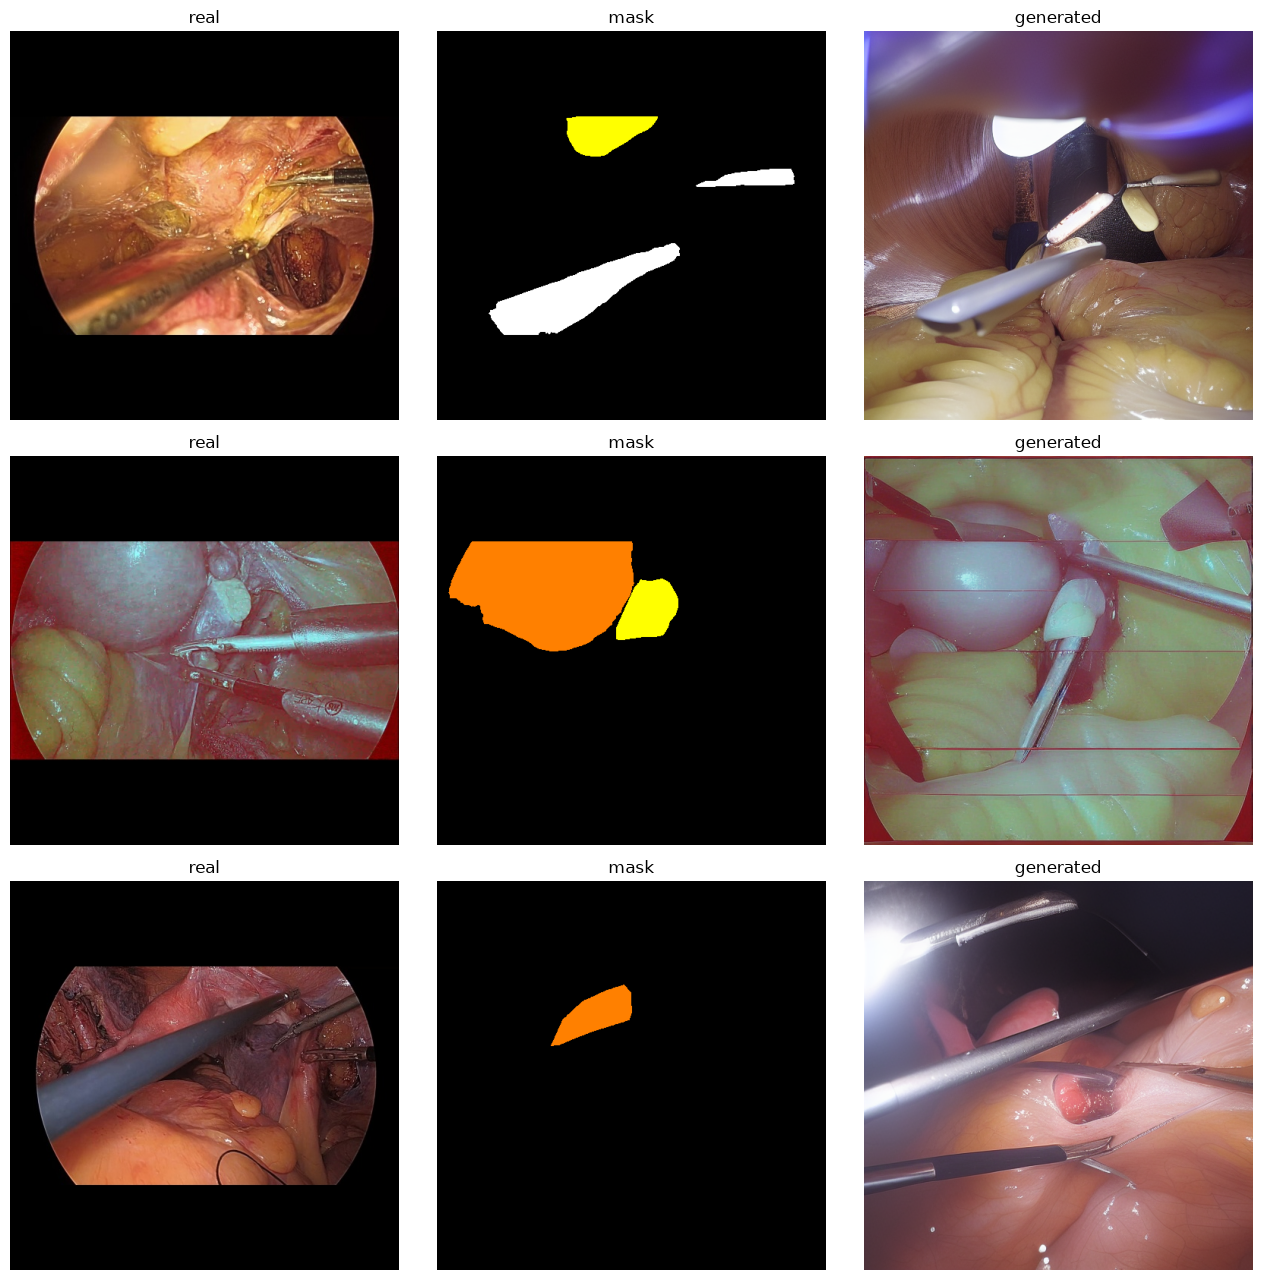

Judge ONE thing: do the generated structures sit where the mask says?
Texture realism matters less -- YOLO learns shape and position.


In [15]:
# 4. QUALITY GATE -- run this before generating thousands of images
#    Real image | its mask | what the model paints from that mask.
#    If column 3 ignores column 2, the ControlNet is undertrained. STOP HERE:
#    more images will not help, more training steps might.
gate = rng.sample(train_records, 3)
fig, axes = plt.subplots(len(gate), 3, figsize=(13, 4.3 * len(gate)))
if len(gate) == 1:
    axes = axes[None, :]

for row, rec in enumerate(gate):
    real = cv2.cvtColor(cv2.imread(str(CONTROLNET_ROOT / rec["image"])), cv2.COLOR_BGR2RGB)
    cond = Image.open(CONTROLNET_ROOT / rec["conditioning_image"]).convert("RGB")
    g = torch.Generator(device="cuda").manual_seed(SEED + row)
    out = pipe(prompt=rec["text"], negative_prompt=NEGATIVE_PROMPT, image=cond,
               num_inference_steps=INFER_STEPS, guidance_scale=GUIDANCE,
               generator=g).images[0]
    for col, (im, ttl) in enumerate([(real, "real"), (np.array(cond), "mask"),
                                     (np.array(out), "generated")]):
        axes[row, col].imshow(im); axes[row, col].set_title(ttl); axes[row, col].axis("off")
plt.tight_layout(); plt.show()

print("Judge ONE thing: do the generated structures sit where the mask says?")
print("Texture realism matters less -- YOLO learns shape and position.")

In [5]:
# 5. Mask utilities
def rgb_to_label(rgb, palette):
    label = np.zeros(rgb.shape[:2], dtype=np.uint8)
    for cid, color in palette.items():
        if cid == 0:
            continue
        label[np.all(rgb == np.array(color, dtype=np.uint8), axis=-1)] = cid
    return label


def label_to_rgb(label, palette):
    rgb = np.zeros((*label.shape, 3), dtype=np.uint8)
    for cid, color in palette.items():
        rgb[label == cid] = color
    return rgb


def load_label(rec):
    bgr = cv2.imread(str(CONTROLNET_ROOT / rec["conditioning_image"]))
    return rgb_to_label(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), palette)


def instances_of(label, cid, min_area=64):
    binary = (label == cid).astype(np.uint8)
    if binary.sum() == 0:
        return []
    n, cc, stats, cents = cv2.connectedComponentsWithStats(binary, 8)
    out = []
    for i in range(1, n):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if area < min_area:
            continue
        x, y = int(stats[i, cv2.CC_STAT_LEFT]), int(stats[i, cv2.CC_STAT_TOP])
        w, h = int(stats[i, cv2.CC_STAT_WIDTH]), int(stats[i, cv2.CC_STAT_HEIGHT])
        out.append({"cid": cid, "mask": (cc[y:y+h, x:x+w] == i).astype(np.uint8),
                    "area": area, "cx": float(cents[i][0]), "cy": float(cents[i][1])})
    return out


def paste_instance(label, inst, cx, cy, scale, rng, min_visible=0.55):
    """Paste on top (nearest the camera). Rejected if it buries an existing
    object below min_visible of its pixels -- that is what creates
    anatomically impossible frames."""
    H, W = label.shape
    m = inst["mask"]
    h, w = m.shape
    nw, nh = max(4, int(round(w * scale))), max(4, int(round(h * scale)))
    if nw >= W or nh >= H:
        return None
    m = cv2.resize(m, (nw, nh), interpolation=cv2.INTER_NEAREST)
    M = cv2.getRotationMatrix2D((nw / 2, nh / 2), rng.uniform(-12, 12), 1.0)
    m = cv2.warpAffine(m, M, (nw, nh), flags=cv2.INTER_NEAREST, borderValue=0)
    if m.sum() == 0:
        return None

    x1, y1 = int(round(cx - nw / 2)), int(round(cy - nh / 2))
    if x1 < 0 or y1 < 0 or x1 + nw > W or y1 + nh > H:
        return None

    before = {int(c): int((label == c).sum()) for c in np.unique(label) if c != 0}
    out = label.copy()
    region = out[y1:y1+nh, x1:x1+nw]
    region[m == 1] = inst["cid"]
    out[y1:y1+nh, x1:x1+nw] = region
    for c, n0 in before.items():
        if n0 and int((out == c).sum()) / n0 < min_visible:
            return None
    return out


def label_to_yolo(label, cid_to_yolo, min_area=64, seg=False):
    H, W = label.shape
    rows = []
    for cid, idx in cid_to_yolo.items():
        binary = (label == cid).astype(np.uint8)
        if binary.sum() == 0:
            continue
        cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            if cv2.contourArea(c) < min_area:
                continue
            if seg:
                ap = cv2.approxPolyDP(c, 0.004 * cv2.arcLength(c, True), True).reshape(-1, 2)
                if len(ap) < 3:
                    continue
                ap = np.clip(ap, [0, 0], [W - 1, H - 1])
                rows.append(f"{idx} " + " ".join(f"{x/W:.6f} {y/H:.6f}" for x, y in ap))
            else:
                x, y, w, h = cv2.boundingRect(c)
                rows.append(f"{idx} {(x+w/2)/W:.6f} {(y+h/2)/H:.6f} {w/W:.6f} {h/H:.6f}")
    return rows

print("mask utilities ready")

mask utilities ready


In [6]:
# 6. Build the instance bank + real placement statistics
inst_img_counts = collections.Counter()
for r in train_records:
    for nm in r.get("classes", []):
        inst_img_counts[nm] += 1
name_to_cid = {v: k for k, v in names.items()}

if not RARE_CLASSES:
    # A class is "rare" only relative to the biggest one. Picking a fixed
    # bottom-3 would boost classes that are already well represented.
    ranked = [(name_to_cid[n], n, c) for n, c in inst_img_counts.most_common()
              if n in name_to_cid]
    if ranked:
        top = ranked[0][2]
        RARE_CLASSES = [cid for cid, _n, c in ranked if c < 0.5 * top][:4]
        if not RARE_CLASSES:
            RARE_CLASSES = [ranked[-1][0]]
            print("No class is below half the largest -- imbalance is mild.")
            print("Boosting only the smallest; consider skipping synthesis entirely.")

print("\nclass image-counts in train split:")
for n, c in inst_img_counts.most_common():
    mark = "  <-- boosting" if name_to_cid.get(n) in RARE_CLASSES else ""
    print(f"  {n:<28} {c:>6}{mark}")
assert RARE_CLASSES, "Could not determine rare classes -- set RARE_CLASSES manually."


# Donor frames: only those that actually contain a rare class.
donor_records = [r for r in train_records
                 if any(names[c] in r.get("classes", []) for c in RARE_CLASSES)]
print(f"{len(donor_records)} donor frames")

bank = {c: [] for c in RARE_CLASSES}
stats = {c: {"cx": [], "cy": [], "scale": []} for c in RARE_CLASSES}
for r in tqdm(donor_records, desc="bank"):
    lab = load_label(r)
    for cid in RARE_CLASSES:
        for inst in instances_of(lab, cid):
            bank[cid].append(inst)
            stats[cid]["cx"].append(inst["cx"] / SIZE)
            stats[cid]["cy"].append(inst["cy"] / SIZE)
            stats[cid]["scale"].append(math.sqrt(inst["area"]) / SIZE)

for cid in RARE_CLASSES:
    print(f"  {names[cid]:<28} {len(bank[cid]):>5} instances banked")
    if not bank[cid]:
        print(f"    !! nothing banked for {names[cid]} -- it cannot be boosted")

# Recipient frames sampled from the whole train split, so pasted objects land in
# varied surroundings rather than only the frames the class already lives in.
recipients = rng.sample(train_records, min(BANK_SAMPLE, len(train_records)))
print(f"{len(recipients)} recipient frames sampled")


def sample_placement(cid, rng, jitter=0.06):
    s = stats[cid]
    if not s["cx"]:
        return None
    i = rng.randrange(len(s["cx"]))
    cx = float(np.clip((s["cx"][i] + rng.uniform(-jitter, jitter)) * SIZE, 0, SIZE - 1))
    cy = float(np.clip((s["cy"][i] + rng.uniform(-jitter, jitter)) * SIZE, 0, SIZE - 1))
    return cx, cy


class image-counts in train split:
  uterus                         6055
  instruments                    4419
  ovary                          2045  <-- boosting
  external iliac artery          1845  <-- boosting
  external iliac vein            1396  <-- boosting
  obturator nerve                 553  <-- boosting
  ureter                          306
  uterine artery                   68
3463 donor frames


bank:   0%|          | 0/3463 [00:00<?, ?it/s]

  ovary                         2438 instances banked
  external iliac artery         2212 instances banked
  external iliac vein           1587 instances banked
  obturator nerve                570 instances banked
1500 recipient frames sampled


composing:   0%|          | 0/3200 [00:00<?, ?it/s]


2148 composed masks from 2148 attempts
instances added: {'ovary': 800, 'external iliac artery': 800, 'external iliac vein': 800, 'obturator nerve': 800}


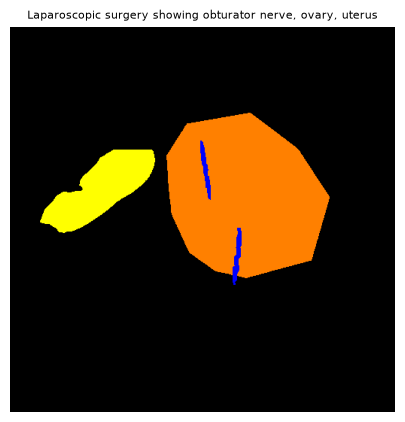

In [7]:
# 7. Compose rebalanced masks
need = {c: TARGET_PER_CLASS for c in RARE_CLASSES if bank[c]}
assert need, "Nothing to boost -- check RARE_CLASSES and the bank output above."

made = {c: 0 for c in need}
composed = []          # (name, label_map, caption)
attempts = 0
MAX_ATTEMPTS = 60 * sum(need.values())

pbar = tqdm(total=sum(need.values()), desc="composing")
while any(made[c] < need[c] for c in need) and attempts < MAX_ATTEMPTS:
    attempts += 1
    rec = rng.choice(recipients)
    lab = load_label(rec)
    added = 0

    for _ in range(rng.randint(1, MAX_PASTES)):
        hungry = [c for c in need if made[c] < need[c]]
        if not hungry:
            break
        cid = rng.choice(hungry)
        inst = rng.choice(bank[cid])
        place = sample_placement(cid, rng)
        if place is None:
            continue
        for _try in range(12):
            cx, cy = sample_placement(cid, rng)
            scale = rng.uniform(0.85, 1.20)
            out = paste_instance(lab, inst, cx, cy, scale, rng)
            if out is not None:
                lab = out
                made[cid] += 1
                added += 1
                pbar.update(1)
                break

    if added == 0:
        continue

    present = sorted({names[int(c)] for c in np.unique(lab) if int(c) in names})
    composed.append((f"syn_{len(composed):06d}", lab,
                     "Laparoscopic surgery showing " + ", ".join(present)))
pbar.close()

print(f"\n{len(composed)} composed masks from {attempts} attempts")
print("instances added:", {names[c]: n for c, n in made.items()})
if attempts >= MAX_ATTEMPTS:
    print("Hit the attempt cap -- placement is being rejected often.")
    print("Loosen min_visible in paste_instance, or lower TARGET_PER_CLASS.")

# Visual check on one composed mask before committing GPU hours
if composed:
    nm, lab, cap = composed[0]
    plt.figure(figsize=(5, 5))
    plt.imshow(label_to_rgb(lab, palette)); plt.axis("off"); plt.title(cap, fontsize=8)
    plt.show()

In [8]:
# 8. Generate images from the composed masks
def _save_batch(batch):
    prompts = [c for _, _, c in batch]
    conds = [Image.fromarray(label_to_rgb(l, palette)) for _, l, _ in batch]
    gens = [torch.Generator(device="cuda").manual_seed(SEED + i)
            for i in range(len(batch))]
    imgs = pipe(prompt=prompts, negative_prompt=[NEGATIVE_PROMPT] * len(batch),
                image=conds, num_inference_steps=INFER_STEPS,
                guidance_scale=GUIDANCE, generator=gens).images
    for (nm, lab, _cap), cond, img in zip(batch, conds, imgs):
        img.save(SYN_IMG_DIR / f"{nm}.jpg", quality=95)
        cond.save(SYN_COND_DIR / f"{nm}.png")
    return len(batch)

failed, done, bs = [], 0, BATCH
i = 0
pbar = tqdm(total=len(composed), desc="generating")
while i < len(composed):
    batch = composed[i:i + bs]
    try:
        done += _save_batch(batch)
        i += len(batch)
        pbar.update(len(batch))
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        if bs > 1:
            bs = 1
            print("OOM -> dropping batch size to 1")
            continue
        failed.append(batch[0][0]); i += 1; pbar.update(1)
    except Exception as e:
        failed.append((batch[0][0], repr(e)[:120])); i += len(batch); pbar.update(len(batch))
pbar.close()

print(f"\nGenerated {done}/{len(composed)} -> {SYN_IMG_DIR}")
if failed:
    print(f"{len(failed)} failures, first few: {failed[:5]}")

generating:   0%|          | 0/2148 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# 9. Export YOLO labels from the composed masks
# The labels come from the layout WE built, so they are exact by construction.
n_det = n_seg = 0
per_class = collections.Counter()
for nm, lab, _cap in tqdm(composed, desc="labels"):
    if not (SYN_IMG_DIR / f"{nm}.jpg").exists():
        continue                     # generation failed for this one
    det = label_to_yolo(lab, cid_to_yolo, seg=False)
    seg = label_to_yolo(lab, cid_to_yolo, seg=True)
    if not det:
        continue
    (SYN_DET_DIR / f"{nm}.txt").write_text("\n".join(det) + "\n")
    (SYN_SEG_DIR / f"{nm}.txt").write_text("\n".join(seg) + "\n")
    n_det += len(det); n_seg += len(seg)
    for r in det:
        per_class[yolo_names[int(r.split()[0])]] += 1

print(f"{n_det} det boxes, {n_seg} seg polygons written")
print("\nSynthetic instances per class:")
for nm_, n in per_class.most_common():
    print(f"  {nm_:<28} {n:>6}")

(SYN_ROOT / "dataset_names.yaml").write_text(
    "names:\n" + "".join(f"  {i}: {n}\n" for i, n in enumerate(yolo_names)))
print("\nWrote", SYN_ROOT / "dataset_names.yaml")

In [ ]:
# 10. Final visual verification -- boxes drawn on generated images
sample = [c for c in composed if (SYN_IMG_DIR / f"{c[0]}.jpg").exists()]
sample = rng.sample(sample, min(3, len(sample)))

fig, axes = plt.subplots(len(sample), 2, figsize=(11, 5 * len(sample)))
if len(sample) == 1:
    axes = axes[None, :]
for row, (nm, lab, cap) in enumerate(sample):
    img = cv2.cvtColor(cv2.imread(str(SYN_IMG_DIR / f"{nm}.jpg")), cv2.COLOR_BGR2RGB).copy()
    for line in (SYN_DET_DIR / f"{nm}.txt").read_text().split("\n"):
        if not line.strip():
            continue
        p = line.split(); idx = int(p[0]); xc, yc, w, h = map(float, p[1:5])
        x1, y1 = int((xc - w/2) * SIZE), int((yc - h/2) * SIZE)
        x2, y2 = int((xc + w/2) * SIZE), int((yc + h/2) * SIZE)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 0), 2)
        cv2.putText(img, yolo_names[idx], (x1, max(14, y1 - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
    axes[row, 0].imshow(label_to_rgb(lab, palette)); axes[row, 0].set_title("composed mask")
    axes[row, 1].imshow(img); axes[row, 1].set_title("generated + YOLO boxes")
    for a in axes[row]: a.axis("off")
plt.tight_layout(); plt.show()

print("Boxes must sit on the structures. If they do, the dataset is usable.")

## Using this with YOLO

```
train: [real_train_images, D:/Study/CDC Project 1/Project/data/synthetic/images]
val:   real_val_images_only
```

Three rules, all non-negotiable:

1. **Synthetic data goes in `train` only.** Never in `val` or `test`. If a
   generated image reaches validation, every number you report is fiction.
2. **Real val must come from held-out videos**, using the `split` field notebook
   02 wrote. Frames from the same procedure are near-duplicates.
3. **Measure the honest thing:** per-class AP on real held-out video, with and
   without the synthetic data. If the rare-class AP does not move, the synthetic
   images are not carrying information — and no amount more of them will help.

Also worth running once: train on **synthetic only**, test on real. If that
scores near zero, the generator is producing surgical-looking texture without
learnable structure, and the whole pipeline needs rethinking rather than scaling.